In [71]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [72]:
df = pd.read_csv(r'D:\IMP  ML  PROJECTS\CAR PRICE PREDICTION\city\MUMBAI\database\cleaned_car_data_Petrol.csv')

In [73]:
df.columns

Index(['Registration Year', 'Insurance', 'Seats', 'Kms Driven', 'Ownership',
       'Engine Displacement', 'Mileage', 'Max_Power_clean', 'Max_Power_RPM',
       'Max_Torque_Nm', 'Max_Torque_RPM', 'Valves Per Cylinder',
       'Turbo Charger', 'Transmission Type', 'Gearbox', 'Petrol Mileage ARAI',
       'Petrol Fuel Tank Capacity', 'Emission Norm Compliance',
       'Front Suspension', 'Rear Suspension', 'Steering Type',
       'Steering Column', 'Front Brake Type', 'Rear Brake Type',
       'Ground Clearance Unladen', 'Wheel Base', 'Price', 'Top Speed',
       'Volume', 'Drive Type_4WD', 'Drive Type_AWD', 'Drive Type_FWD',
       'Drive Type_RWD', 'Engine Type_Standard',
       'Engine Type_Standard Brand Engine', 'Engine Type_Turbocharged',
       'Engine Type_V-Type', 'Fuel Supply System_Direct Injection',
       'Fuel Supply System_EFI', 'Fuel Supply System_MPFi',
       'Fuel Supply System_Other', 'Gross Weight'],
      dtype='object')

In [74]:
# Pick all the non numeric features
cat_col = []
for col in df.columns:
    if df[col].dtype == 'object':
        cat_col.append(col)
print(cat_col)

[]


In [75]:
continuous_cols = [col for col in df.columns if df[col].nunique() > 2]
binary_cols = [col for col in df.columns if df[col].nunique() <= 2]

print(f"Scaling these: {continuous_cols}")
print(f"Leaving these as is: {binary_cols}")

Scaling these: ['Registration Year', 'Insurance', 'Seats', 'Kms Driven', 'Ownership', 'Engine Displacement', 'Mileage', 'Max_Power_clean', 'Max_Power_RPM', 'Max_Torque_Nm', 'Max_Torque_RPM', 'Valves Per Cylinder', 'Gearbox', 'Petrol Mileage ARAI', 'Petrol Fuel Tank Capacity', 'Emission Norm Compliance', 'Rear Suspension', 'Steering Type', 'Steering Column', 'Rear Brake Type', 'Ground Clearance Unladen', 'Wheel Base', 'Price', 'Top Speed', 'Volume', 'Gross Weight']
Leaving these as is: ['Turbo Charger', 'Transmission Type', 'Front Suspension', 'Front Brake Type', 'Drive Type_4WD', 'Drive Type_AWD', 'Drive Type_FWD', 'Drive Type_RWD', 'Engine Type_Standard', 'Engine Type_Standard Brand Engine', 'Engine Type_Turbocharged', 'Engine Type_V-Type', 'Fuel Supply System_Direct Injection', 'Fuel Supply System_EFI', 'Fuel Supply System_MPFi', 'Fuel Supply System_Other']


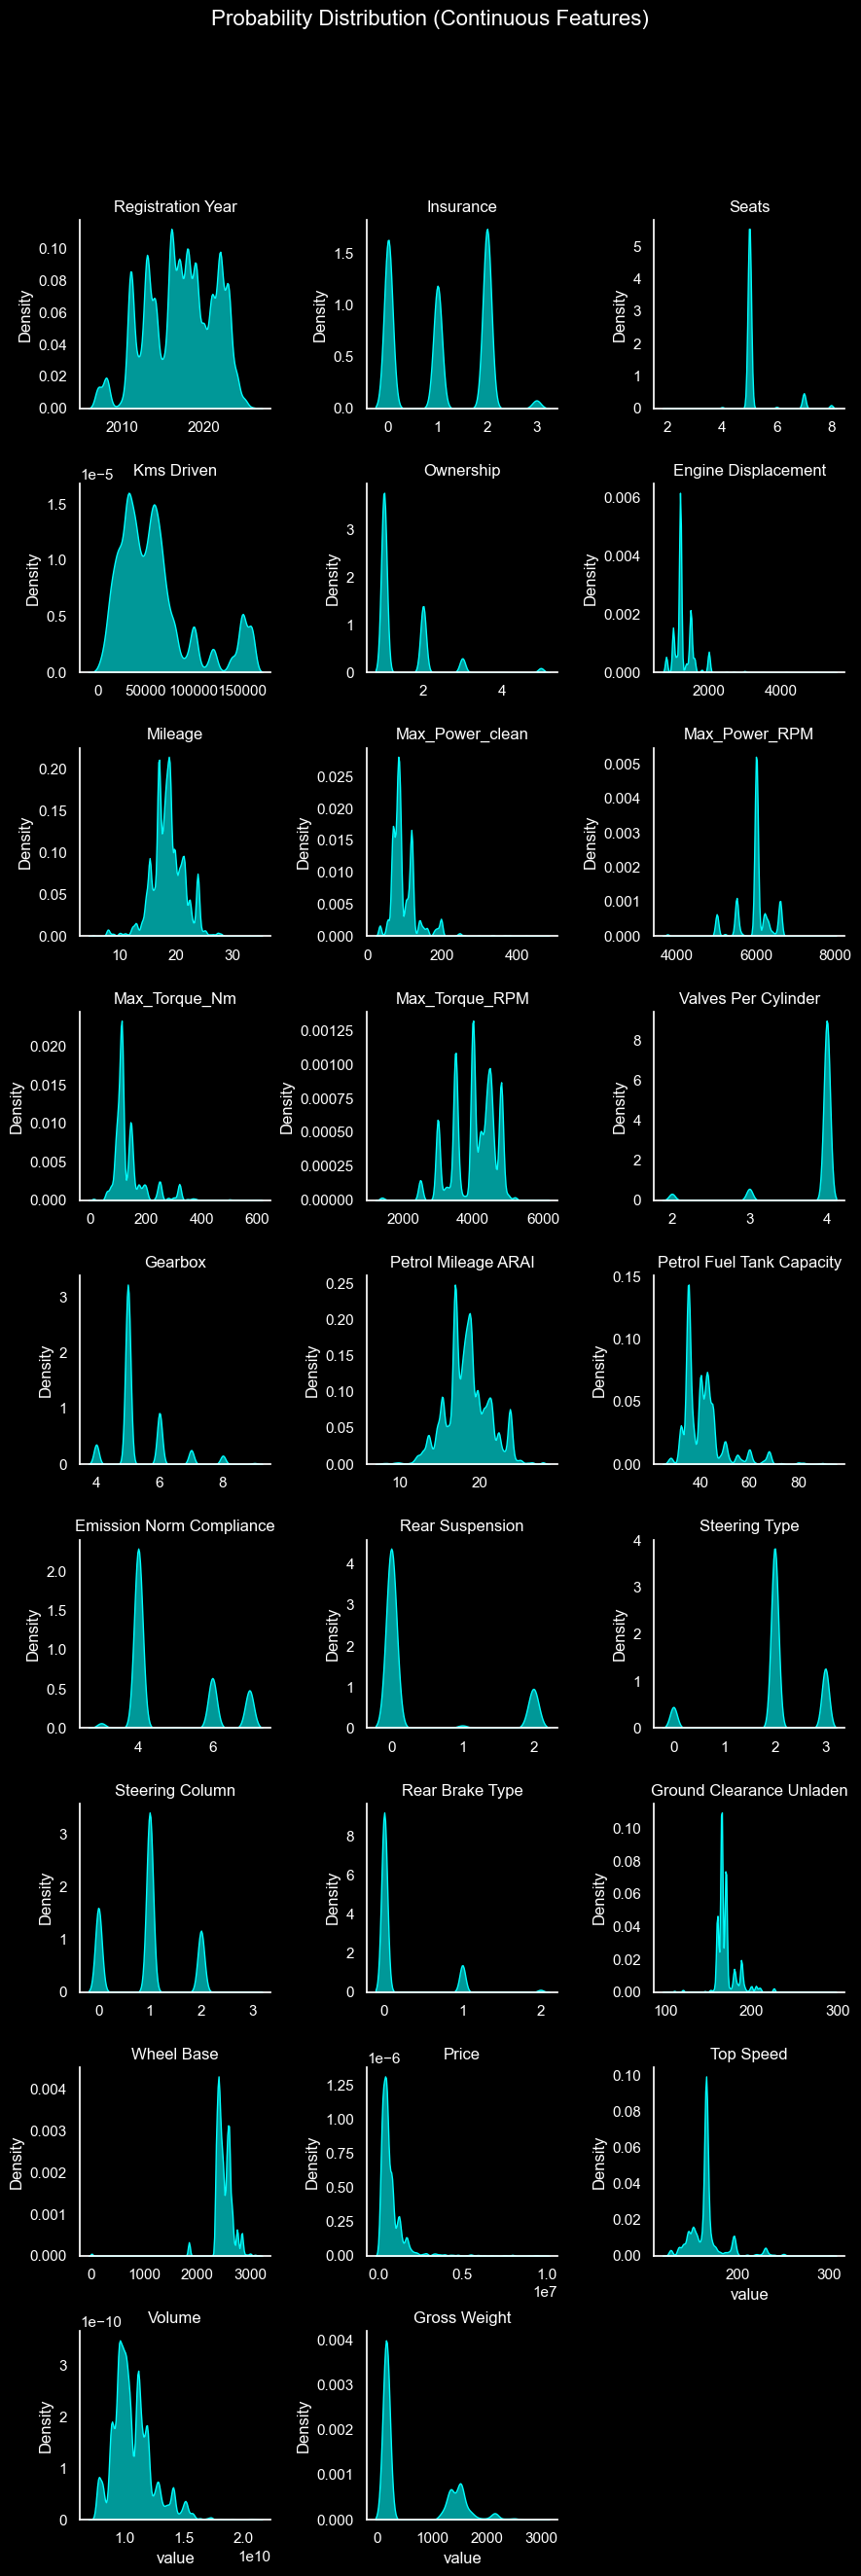

In [76]:
sns.set_theme(style="dark", palette="muted")
plt.style.use('dark_background')

df_melted_cont = df[continuous_cols].melt()

g = sns.FacetGrid(df_melted_cont, col="variable", col_wrap=3, 
                  sharex=False, sharey=False, despine=True)

g.map(sns.kdeplot, "value", fill=True, color="cyan", bw_adjust=0.5, alpha=0.6)

g.set_titles("{col_name}", color="white", fontsize=12)
plt.subplots_adjust(top=0.9, hspace=0.4)
g.fig.suptitle('Probability Distribution (Continuous Features)', color="white", fontsize=16)

plt.show()

### Applying the standard scaling 

In [77]:
# NaN columns 
for col in df.columns:
    if df[col].isnull().sum() > 0:
        print(f"{col} has {df[col].isnull().sum()} missing values") 

Turbo Charger has 32 missing values
Gearbox has 18 missing values
Price has 62 missing values


In [78]:
df['Turbo Charger'] = df['Turbo Charger'].fillna(0)

df['Gearbox'] = df['Gearbox'].fillna(df['Gearbox'].mode()[0])

df['Price'] = df['Price'].fillna(df['Price'].mode()[0])

In [79]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, FunctionTransformer

# 1. Define feature groups (excluding Price)
continuous_features = [
    "Registration Year", "Engine Displacement", "Max_Power_RPM", 
    "Max_Torque_Nm", "Max_Torque_RPM", "Petrol Mileage ARAI", 
    "Petrol Fuel Tank Capacity", "Ground Clearance Unladen", 
    "Wheel Base", "Top Speed", "Volume", "Gross Weight"
]
skewed_features = ["Max_Power_clean", "Kms Driven"]

X_raw = df.drop(columns=['Price'])
y = df['Price']

log_transformer = FunctionTransformer(np.log1p, validate=True)

preprocessor = ColumnTransformer(
    transformers=[
        ('log', log_transformer, skewed_features),
        ('num_scaler', StandardScaler(), continuous_features),
    ],
    remainder='passthrough' 
)

X_transformed = preprocessor.fit_transform(X_raw)

remaining_cols = [c for c in X_raw.columns if c not in (skewed_features + continuous_features)]
all_col_names = skewed_features + continuous_features + remaining_cols

X_final_df = pd.DataFrame(X_transformed, columns=all_col_names)

print(f"Is 'Price' in features? {'Price' in X_final_df.columns}")

Is 'Price' in features? False


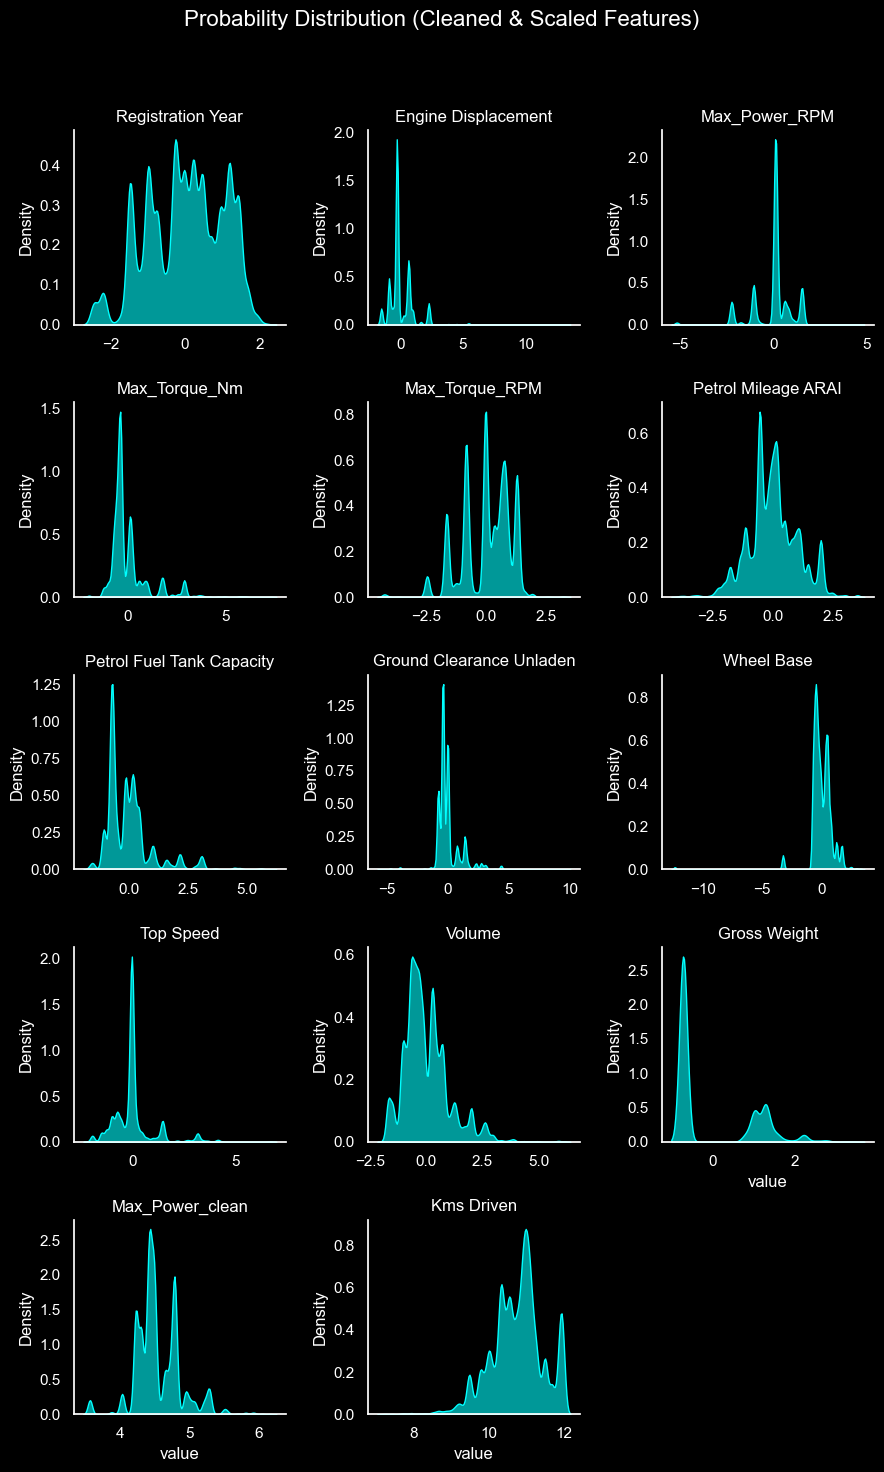

In [80]:
cols_to_plot = continuous_features + skewed_features

sns.set_theme(style="dark", palette="muted")
plt.style.use('dark_background')

df_melted_cont = X_final_df[cols_to_plot].melt()

g = sns.FacetGrid(df_melted_cont, col="variable", col_wrap=3, 
                  sharex=False, sharey=False, despine=True)

g.map(sns.kdeplot, "value", fill=True, color="cyan", bw_adjust=0.5, alpha=0.6)

g.set_titles("{col_name}", color="white", fontsize=12)
plt.subplots_adjust(top=0.9, hspace=0.4)
g.fig.suptitle('Probability Distribution (Cleaned & Scaled Features)', color="white", fontsize=16)

plt.show()

In [81]:
X_final_df.columns

Index(['Max_Power_clean', 'Kms Driven', 'Registration Year',
       'Engine Displacement', 'Max_Power_RPM', 'Max_Torque_Nm',
       'Max_Torque_RPM', 'Petrol Mileage ARAI', 'Petrol Fuel Tank Capacity',
       'Ground Clearance Unladen', 'Wheel Base', 'Top Speed', 'Volume',
       'Gross Weight', 'Insurance', 'Seats', 'Ownership', 'Mileage',
       'Valves Per Cylinder', 'Turbo Charger', 'Transmission Type', 'Gearbox',
       'Emission Norm Compliance', 'Front Suspension', 'Rear Suspension',
       'Steering Type', 'Steering Column', 'Front Brake Type',
       'Rear Brake Type', 'Drive Type_4WD', 'Drive Type_AWD', 'Drive Type_FWD',
       'Drive Type_RWD', 'Engine Type_Standard',
       'Engine Type_Standard Brand Engine', 'Engine Type_Turbocharged',
       'Engine Type_V-Type', 'Fuel Supply System_Direct Injection',
       'Fuel Supply System_EFI', 'Fuel Supply System_MPFi',
       'Fuel Supply System_Other'],
      dtype='object')

In [82]:
X = X_final_df.drop(columns=['Price'], errors='ignore') 
y_log = np.log1p(df['Price'])

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_log,
    test_size=0.2,
    random_state=42
)
print(f"Features in X_train: {X_train.shape[1]}")
print(f"Target variable is 'Price': {y_train.name}")

Features in X_train: 41
Target variable is 'Price': Price


In [83]:
y_test.head()

2148    12.611541
1044    13.262127
3319    12.013707
439     12.206078
3516    12.421188
Name: Price, dtype: float64

In [84]:
# Applying the lasso regression
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, r2_score

lasso = Lasso(alpha=0.01)
lasso.fit(X_train, y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",0.01
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [85]:
y_pred = lasso.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R2 Score: {r2}")

Mean Squared Error: 0.5736944008570957
R2 Score: 0.019838368288257135


In [86]:
from sklearn.linear_model import LassoCV

# 1. Use LassoCV to find the best alpha automatically
# We test 100 different alphas to see which one gives the best R2
lasso_cv = LassoCV(alphas=None, cv=5, max_iter=10000)
lasso_cv.fit(X_train, y_train)

# 2. See what alpha it chose
print(f"Best Alpha found: {lasso_cv.alpha_}")

# 3. Predict and check the NEW R2
y_pred = lasso_cv.predict(X_test)
print(f"Improved R2 Score: {r2_score(y_test, y_pred)}")

Best Alpha found: 0.004682951661722597
Improved R2 Score: 0.02750772726907036
